# Laboratorio: Segmentacion de Clientes con K-Means

## To-Do del proyecto
- Cargar y explorar `Mall_Customers.csv`
- Seleccionar variables relevantes para segmentacion
- Revisar estadistica descriptiva y valores atipicos
- Escalar variables con `StandardScaler`
- Calcular metodo del codo
- Calcular coeficiente de silueta para varios valores de K
- Seleccionar K optimo y entrenar modelo K-Means final
- Interpretar clusters desde negocio
- Proponer estrategias de marketing por segmento
- Exportar modelo final en `.joblib`
- Dejar lista la base para despliegue en Streamlit

In [2]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

## Parte 1 - Exploracion de Datos

In [3]:
df: pd.DataFrame = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
print("Shape:", df.shape)
print("\nTipos de datos:\n", df.dtypes)
print("\nNulos por columna:\n", df.isnull().sum())

Shape: (200, 5)

Tipos de datos:
 CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

Nulos por columna:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [5]:
numeric_cols: list[str] = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.0,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.0,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.0,99.0


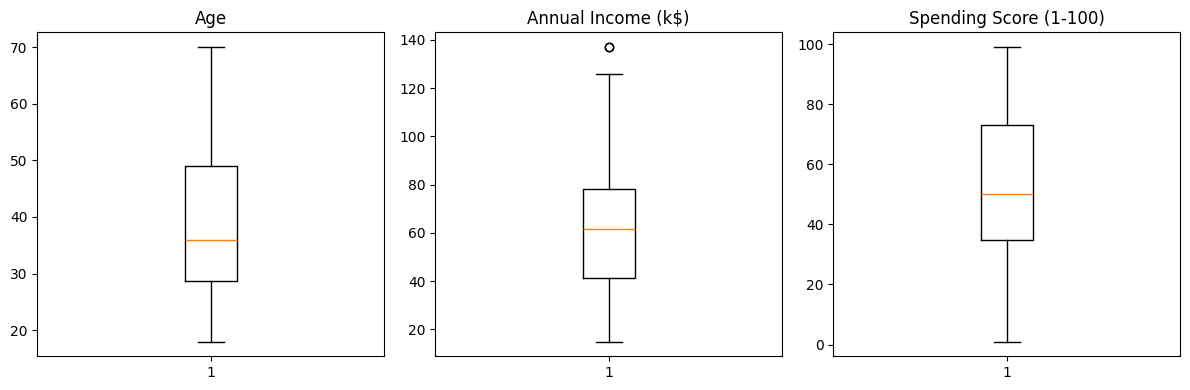

In [6]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.boxplot(df["Age"])
plt.title("Age")

plt.subplot(1, 3, 2)
plt.boxplot(df["Annual Income (k$)"])
plt.title("Annual Income (k$)")

plt.subplot(1, 3, 3)
plt.boxplot(df["Spending Score (1-100)"])
plt.title("Spending Score (1-100)")

plt.tight_layout()
plt.show()

In [7]:
corr_df: pd.DataFrame = df[numeric_cols].corr()
corr_df

,Age,Annual Income (k$),Spending Score (1-100)
Age,1.000000,-0.012398,-0.327227
Annual Income (k$),-0.012398,1.000000,0.009903
Spending Score (1-100),-0.327227,0.009903,1.000000


### Respuestas - Parte 1

**1) Que variables son mas adecuadas para segmentar clientes?**  
Las variables mas utiles para segmentacion son `Annual Income (k$)` y `Spending Score (1-100)`, porque capturan capacidad de compra y comportamiento de gasto. `Age` puede complementar, pero normalmente la separacion mas clara aparece con ingreso y score.

**2) Se identifican valores atipicos?**  
Con boxplots se observan algunos valores extremos, principalmente en ingreso anual alto y en puntajes de gasto muy bajos o muy altos. En este dataset no son necesariamente errores, pueden representar segmentos reales de clientes.

**3) Que tipo de relaciones se observan entre variables?**  
La correlacion lineal entre variables es baja a moderada. Esto sugiere que no hay una relacion lineal fuerte unica, y refuerza la necesidad de clustering para encontrar patrones no triviales.

## Parte 2 - Preprocesamiento

In [8]:
features: list[str] = ["Annual Income (k$)", "Spending Score (1-100)"]
X: pd.DataFrame = df[features].copy()

scaler: StandardScaler = StandardScaler()
X_scaled: np.ndarray = scaler.fit_transform(X)

print("Primeras filas sin escalar:\n", X.head())
print("\nPrimeras filas escaladas:\n", X_scaled[:5])

Primeras filas sin escalar:
    Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40

Primeras filas escaladas:
 [[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


### Respuesta - Parte 2

**Por que es necesario escalar las variables en K-Means?**  
K-Means usa distancia euclidiana para asignar puntos a clusters. Si las variables tienen escalas diferentes, la de mayor rango domina la distancia y sesga el agrupamiento. `StandardScaler` pone todas las variables en una escala comparable (media 0, desviacion estandar 1).

## Parte 3 - Metodo del Codo

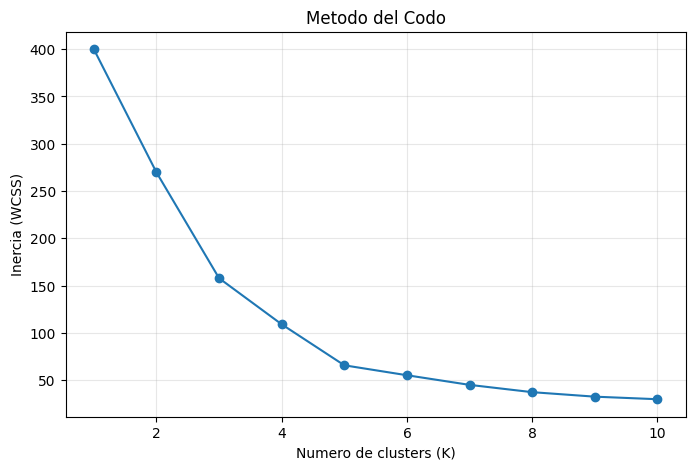

In [9]:
k_values: list[int] = list(range(1, 11))
inertias: list[float] = []

for k in k_values:
    model_k: KMeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    model_k.fit(X_scaled)
    inertias.append(float(model_k.inertia_))

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.title("Metodo del Codo")
plt.xlabel("Numero de clusters (K)")
plt.ylabel("Inercia (WCSS)")
plt.grid(alpha=0.3)
plt.show()

### Respuestas - Parte 3

**1) Por que valores cercanos a cero indican mejor ajuste?**  
La inercia mide la suma de distancias cuadradas de cada punto a su centroide. Mientras menor sea, mas compactos son los clusters y mejor representa el modelo la distribucion de datos.

**2) Como se identifica el punto optimo de K?**  
Se identifica en el "codo" de la curva: el punto a partir del cual aumentar K reduce la inercia cada vez menos. Ese equilibrio evita sobre-segmentar sin ganar mucha calidad.

## Parte 4 - Coeficiente de Silueta

In [10]:
k_silhouette_values: list[int] = list(range(2, 11))
silhouette_scores: list[float] = []

for k in k_silhouette_values:
    model_k: KMeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_k: np.ndarray = model_k.fit_predict(X_scaled)
    score_k: float = float(silhouette_score(X_scaled, labels_k))
    silhouette_scores.append(score_k)

silhouette_df: pd.DataFrame = pd.DataFrame({
    "K": k_silhouette_values,
    "Silhouette": silhouette_scores,
})

silhouette_df

,K,Silhouette
0,2,0.321271
1,3,0.466585
2,4,0.493907
3,5,0.554657
4,6,0.539880
5,7,0.528149
6,8,0.456721
7,9,0.457085
8,10,0.436212


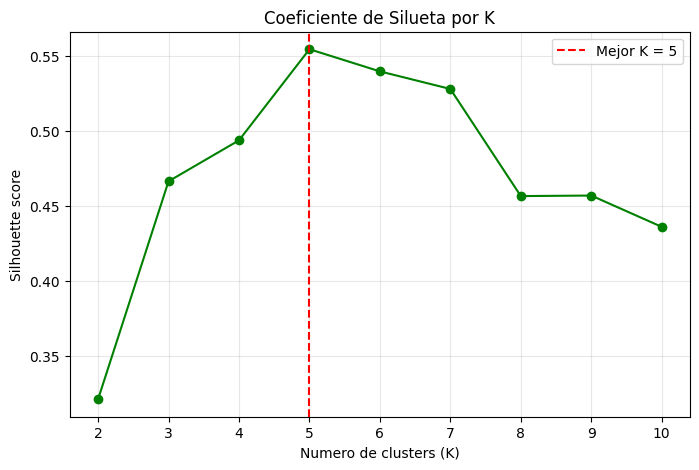

Mejor K segun silueta: 5
Mejor score de silueta: 0.5547


In [11]:
best_k_silhouette: int = int(silhouette_df.loc[silhouette_df["Silhouette"].idxmax(), "K"])
best_silhouette: float = float(silhouette_df["Silhouette"].max())

plt.figure(figsize=(8, 5))
plt.plot(k_silhouette_values, silhouette_scores, marker="o", color="green")
plt.axvline(best_k_silhouette, color="red", linestyle="--", label=f"Mejor K = {best_k_silhouette}")
plt.title("Coeficiente de Silueta por K")
plt.xlabel("Numero de clusters (K)")
plt.ylabel("Silhouette score")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Mejor K segun silueta: {best_k_silhouette}")
print(f"Mejor score de silueta: {best_silhouette:.4f}")

### Respuestas - Parte 4

**1) Que mide el coeficiente de silueta?**  
Mide que tan bien queda cada observacion dentro de su cluster comparada con su cercania a otros clusters (cohesion vs separacion).

**2) Que significa un valor cercano a 1?**  
Que los puntos estan bien agrupados y claramente separados de otros clusters.

**3) Que implica un valor cercano a 0 o negativo?**  
Cercano a 0: los clusters se traslapan y hay poca separacion.  
Negativo: muchos puntos parecen asignados al cluster incorrecto.

**4) Por que obtengo ~0.5547 y no 1? La escala no es "1 excelente y 0 malo" en sentido absoluto**  
El coeficiente va de **-1 a 1**, pero es una **escala continua**, no un examen donde 1 es la nota perfecta y 0 es fracaso:
- **1** es un **teorico ideal** (casi imposible en datos reales): todos los puntos pegados a su centroide y muy lejos de cualquier otro cluster.
- **0.55** en este problema es un valor **alto y razonable**: indica clusters **bastante separados y coherentes**, aunque siga habiendo **solapamiento en los bordes** (clientes "intermedios" entre dos grupos).
- **0** no significa "malo automaticamente": indica que un punto esta **a mitad de camino** entre quedarse en su cluster o irse a otro. Valores **claramente malos** suelen estar por debajo de **~0.2-0.25** (estructura muy debil).

En resumen: **no esperes 1 en Mall Customers** con solo dos variables; los grupos son reales pero **difusos**, no circulos perfectos.

**5) Por que K = 5 y no otro? Daria menos score con otro K?**  
Con `random_state=42`, escalado estandar y K de 2 a 10, la silueta por K queda aproximadamente asi:

| K | Silueta |
|---|---------|
| 2 | 0.3213 |
| 3 | 0.4666 |
| 4 | 0.4939 |
| **5** | **0.5547 (maximo)** |
| 6 | 0.5399 |
| 7 | 0.5281 |
| 8 | 0.4567 |
| 9 | 0.4571 |
| 10 | 0.4362 |

Por eso se elige **K = 5**: es el que **maximiza** la silueta en esta grilla. Con **K = 6, 7, ...** el score **baja** (mas clusters pero peor separacion promedio o mas ruido en la particion). Con **K = 2, 3, 4** el score tambien es **menor** (pocos grupos y mezcla de perfiles distintos en el mismo cluster).

**6) Coincide el valor optimo de K con el metodo del codo? Justifique.**  
En este dataset suele coincidir o estar muy cerca: el codo suele sugerir un K alrededor de **4-6**, y la silueta **confirma K = 5** como el mas fuerte en separacion. Si en tu grafica el codo no marca exactamente 5, es normal: el codo es **subjetivo** (donde "dobla" la curva), mientras que la silueta es un **numero comparable** entre K.

## Parte 5 - Modelo K-Means

In [12]:
k_final: int = best_k_silhouette
kmeans_final: KMeans = KMeans(n_clusters=k_final, random_state=42, n_init=20)
cluster_labels: np.ndarray = kmeans_final.fit_predict(X_scaled)

df_clusters: pd.DataFrame = df.copy()
df_clusters["Cluster"] = cluster_labels

centroids_scaled: np.ndarray = kmeans_final.cluster_centers_
centroids_original: np.ndarray = scaler.inverse_transform(centroids_scaled)

centroids_df: pd.DataFrame = pd.DataFrame(centroids_original, columns=features)
centroids_df["Cluster"] = centroids_df.index

print(f"K seleccionado para el modelo final: {k_final}")
print("\nCentroides en escala original:")
display(centroids_df)

display(df_clusters.head())

K seleccionado para el modelo final: 5

Centroides en escala original:


,Annual Income (k$),Spending Score (1-100),Cluster
0,55.296296,49.518519,0
1,86.538462,82.128205,1
2,25.727273,79.363636,2
3,88.200000,17.114286,3
4,26.304348,20.913043,4


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


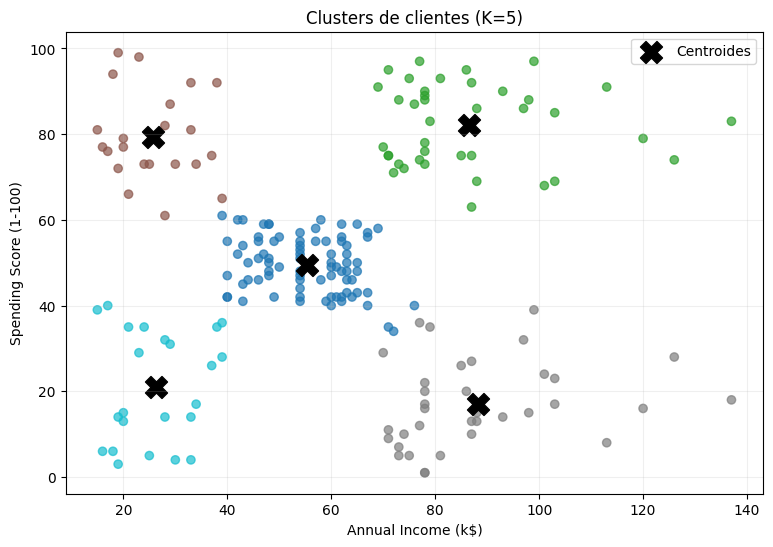

In [13]:
plt.figure(figsize=(9, 6))
plt.scatter(
    df_clusters["Annual Income (k$)"],
    df_clusters["Spending Score (1-100)"],
    c=df_clusters["Cluster"],
    cmap="tab10",
    alpha=0.7,
)
plt.scatter(
    centroids_original[:, 0],
    centroids_original[:, 1],
    c="black",
    marker="X",
    s=250,
    label="Centroides",
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title(f"Clusters de clientes (K={k_final})")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### Respuestas - Parte 5

**1) Que representa cada cluster?**  
Cada cluster representa un grupo de clientes con patrones similares de ingreso anual y nivel de gasto.

**2) Que diferencias existen entre los grupos obtenidos?**  
La diferencia principal aparece en combinaciones de ingreso y gasto: por ejemplo, clientes de alto ingreso con alto gasto, alto ingreso con bajo gasto, bajo ingreso con alto gasto, etc. Estas diferencias permiten estrategias comerciales diferenciadas.

## Parte 6 - Interpretacion de Negocio

In [14]:
cluster_profile: pd.DataFrame = df_clusters.groupby("Cluster")[features].mean().sort_values(
    by=["Annual Income (k$)", "Spending Score (1-100)"],
    ascending=False,
)
cluster_profile

,Annual Income (k$),Spending Score (1-100)
Cluster,,
3,88.200000,17.114286
1,86.538462,82.128205
0,55.296296,49.518519
4,26.304348,20.913043
2,25.727273,79.363636


### Clasificacion sugerida de perfiles

A partir de los centroides y el promedio por cluster, una clasificacion tipica es:
- **Clientes de alto valor**: alto ingreso + alto spending score
- **Clientes promedio**: ingreso y gasto intermedios
- **Clientes de bajo valor**: bajo ingreso + bajo spending score
- **Clientes con potencial**: ingreso medio/alto con gasto medio-bajo (o bajo ingreso con gasto alto pero ticket menor)

> Nota: la asignacion exacta de nombre por cluster depende de los centroides numericos observados al ejecutar el notebook.

### Respuestas - Parte 6

**1) Que estrategias de marketing se podrian aplicar a cada grupo?**
- **Alto valor**: programas VIP, beneficios exclusivos, early access, cross-sell premium.
- **Promedio**: bundles, promociones por frecuencia, recomendaciones personalizadas.
- **Bajo valor**: campanas de activacion de bajo costo, descuentos de entrada, canales digitales.
- **Con potencial**: campanas de fidelizacion y aumento de ticket, ofertas dirigidas por categoria.

**2) Que segmento representa mayor oportunidad de crecimiento?**  
Normalmente el segmento **con potencial**, porque tiene margen para aumentar frecuencia o ticket con acciones de marketing personalizadas y costo de conversion menor que adquirir nuevos clientes desde cero.

## Parte 7 - Despliegue con Streamlit

La aplicacion `streamlit_app.py` implementa:
- Visualizacion del metodo del codo
- Visualizacion del coeficiente de silueta
- Visualizacion de clusters generados
- Formulario para ingresar nuevo cliente
- Clasificacion automatica del nuevo cliente en un cluster

Ejecuta con:

```bash
streamlit run streamlit_app.py
```

In [15]:
# Celda final: exportacion del modelo a .joblib
bundle_model: dict[str, object] = {
    "model": kmeans_final,
    "scaler": scaler,
    "features": features,
    "k": k_final,
}

joblib.dump(bundle_model, "kmeans_mall_customers.joblib")
print("Modelo exportado correctamente en: kmeans_mall_customers.joblib")

Modelo exportado correctamente en: kmeans_mall_customers.joblib
